# <center>  **<span style="font-size:80px;">Exploración de los Datos</span>** </center>

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import sys
import os


from pathlib import Path

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report
)


sys.path.append(os.path.abspath(os.path.join("..")))
from src.config import Paths
from src.config import DatasetKeys

In [55]:
seed = 80
images_path = Path("./AMAEM")
images_path.mkdir(parents=True, exist_ok=True)

# Renombrado

In [56]:
df = pd.read_csv(Paths.DATA / "AMAEM.csv")

In [57]:
df = df.rename(columns={
    "Barrio": DatasetKeys.BARRIO, 
    "Uso": DatasetKeys.USO, 
    "Fecha (aaaa/mm/dd)": DatasetKeys.FECHA,
    "Consumo (litros)": DatasetKeys.CONSUMO,
    "Nº Contratos" : DatasetKeys.NUM_CONTRATOS
})

# Estructura General

In [58]:
df.shape

(5796, 5)

In [59]:
df.dtypes

barrio           str
uso              str
fecha            str
consumo          str
num_contratos    str
dtype: object

In [60]:
df.head()

,barrio,uso,fecha,consumo,num_contratos
0,10-FLORIDA BAJA,COMERCIAL,2022/01/31,"511,019",91
1,10-FLORIDA BAJA,DOMESTICO,2022/01/31,"29,205,005","4,665"
2,10-FLORIDA BAJA,NO DOMESTICO,2022/01/31,"4,362,320",418
3,11-CIUDAD DE ASIS,COMERCIAL,2022/01/31,"1,700,222",87
4,11-CIUDAD DE ASIS,DOMESTICO,2022/01/31,"14,650,197","2,259"


In [61]:
df.isnull().sum()

barrio            0
uso               0
fecha             0
consumo          21
num_contratos    21
dtype: int64

# Manejo de Valores Faltantes

In [62]:
df[df[DatasetKeys.CONSUMO].isna()]

,barrio,uso,fecha,consumo,num_contratos
81,35-VIRGEN DEL CARMEN,COMERCIAL,2022/01/31,NaN,NaN
152,TABARCA,COMERCIAL,2022/01/31,NaN,NaN
242,35-VIRGEN DEL CARMEN,COMERCIAL,2022/02/28,NaN,NaN
313,TABARCA,COMERCIAL,2022/02/28,NaN,NaN
403,35-VIRGEN DEL CARMEN,COMERCIAL,2022/03/31,NaN,NaN
564,35-VIRGEN DEL CARMEN,COMERCIAL,2022/04/30,NaN,NaN
725,35-VIRGEN DEL CARMEN,COMERCIAL,2022/05/31,NaN,NaN
886,35-VIRGEN DEL CARMEN,COMERCIAL,2022/06/30,NaN,NaN
957,TABARCA,COMERCIAL,2022/06/30,NaN,NaN
1279,TABARCA,COMERCIAL,2022/08/31,NaN,NaN


In [63]:
df[df[DatasetKeys.NUM_CONTRATOS].isna()]

,barrio,uso,fecha,consumo,num_contratos
81,35-VIRGEN DEL CARMEN,COMERCIAL,2022/01/31,NaN,NaN
152,TABARCA,COMERCIAL,2022/01/31,NaN,NaN
242,35-VIRGEN DEL CARMEN,COMERCIAL,2022/02/28,NaN,NaN
313,TABARCA,COMERCIAL,2022/02/28,NaN,NaN
403,35-VIRGEN DEL CARMEN,COMERCIAL,2022/03/31,NaN,NaN
564,35-VIRGEN DEL CARMEN,COMERCIAL,2022/04/30,NaN,NaN
725,35-VIRGEN DEL CARMEN,COMERCIAL,2022/05/31,NaN,NaN
886,35-VIRGEN DEL CARMEN,COMERCIAL,2022/06/30,NaN,NaN
957,TABARCA,COMERCIAL,2022/06/30,NaN,NaN
1279,TABARCA,COMERCIAL,2022/08/31,NaN,NaN


A la hora de realizar el procesamiento sobre nuestros datos deberemos tener en cuenta que los siguientes barrios no cuentan con información sobre el contrato con uso Comercial:

- 35-VIRGEN DEL CARMEN
- TABARCA
- REBOLLEDO

In [64]:
# Eliminamos todos los nulos (al no representar gran parte de nuestros datos)
df = df.dropna()

# Conversión de datos

In [65]:
# Eliminamos las comas y convertimos a entero
for key in [DatasetKeys.CONSUMO, DatasetKeys.NUM_CONTRATOS]:
    df[key] = df[key].str.replace(",", "").astype(int)

In [66]:
df.dtypes

barrio             str
uso                str
fecha              str
consumo          int64
num_contratos    int64
dtype: object

# Tratamiento de Outliers

In [67]:
features = df.select_dtypes(include=["number"]).columns

In [68]:
def plot_features(feature):
    # Cálculo de IQR
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[feature] < limite_inferior) | (df[feature] > limite_superior)]
    print(f"{feature:<15} | Outliers: {len(outliers)}")

    # Configuración de estilo
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # 1. Boxplot + Strip Plot (Para ver los puntos reales)
    sns.boxplot(x=df[feature], ax=axes[0], color="#a8dadc", fliersize=5)
    # El strip plot "dibuja" los puntos encima
    sns.stripplot(x=df[feature], ax=axes[0], color="#457b9d", alpha=0.2, jitter=0.4)
    axes[0].set_title(f"Distribución y Outliers: {feature}")

    # 2. Histograma + KDE (Para ver la densidad de los valores)
    sns.histplot(df[feature], kde=True, ax=axes[1], color="#1d3557")
    axes[1].axvline(limite_inferior, color="red", linestyle="--", label="Límite IQR")
    axes[1].axvline(limite_superior, color="red", linestyle="--")
    axes[1].set_title(f"Histograma de {feature}")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(images_path / f"{feature}.png")

consumo         | Outliers: 698
num_contratos   | Outliers: 929


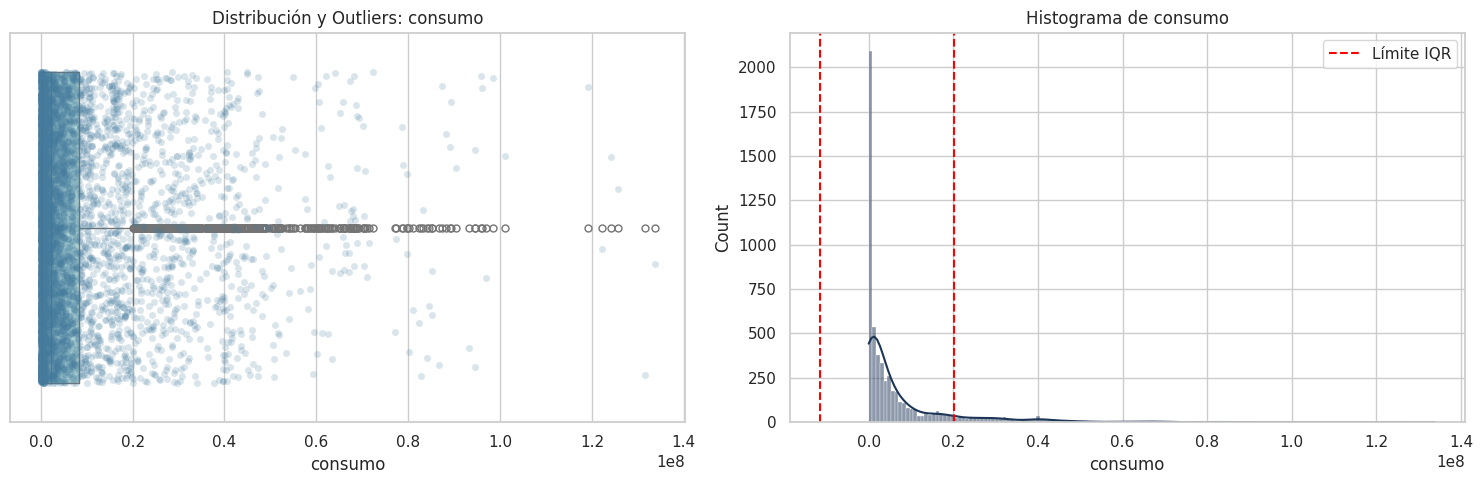

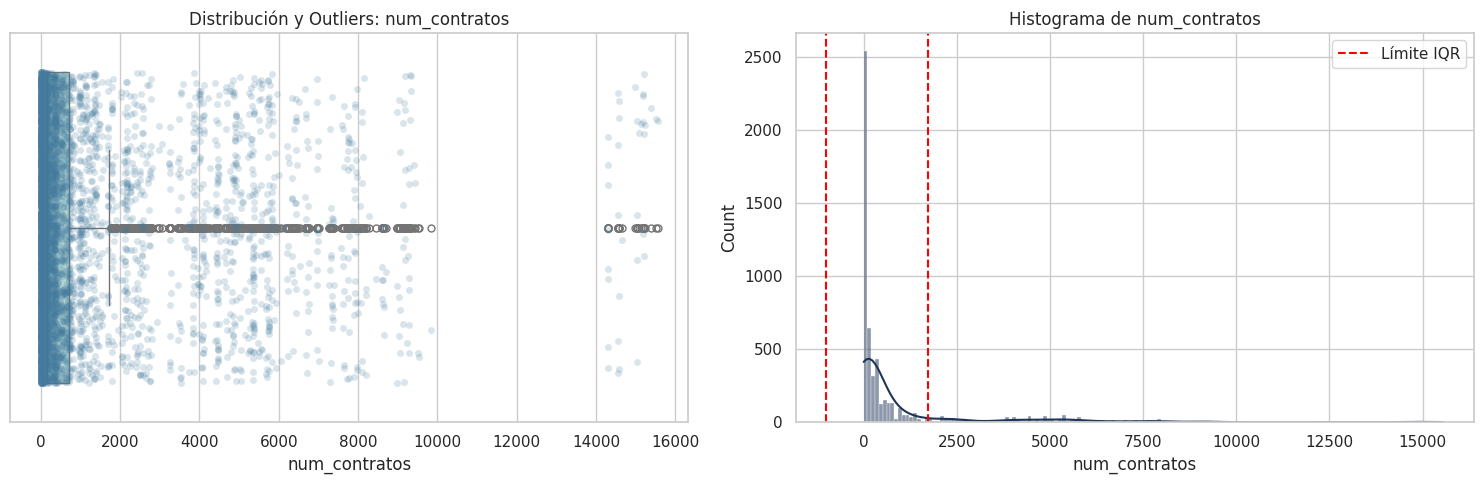

In [69]:
for feature in features:
    plot_features(feature)

# Codificación de Variables

In [70]:
dummies = pd.get_dummies(df[DatasetKeys.USO], prefix=DatasetKeys.USO, dtype=int)
df = pd.concat([df, dummies], axis=1)

df.tail()

,barrio,uso,fecha,consumo,num_contratos,uso_COMERCIAL,uso_DOMESTICO,uso_NO DOMESTICO
5791,VERDEGAS,DOMESTICO,2024/12/31,1819211,220,0,1,0
5792,VERDEGAS,NO DOMESTICO,2024/12/31,63675,5,0,0,1
5793,VILLAFRANQUEZA,COMERCIAL,2024/12/31,3699499,10,1,0,0
5794,VILLAFRANQUEZA,DOMESTICO,2024/12/31,11106866,1471,0,1,0
5795,VILLAFRANQUEZA,NO DOMESTICO,2024/12/31,8091294,115,0,0,1


# Estadística Descriptiva

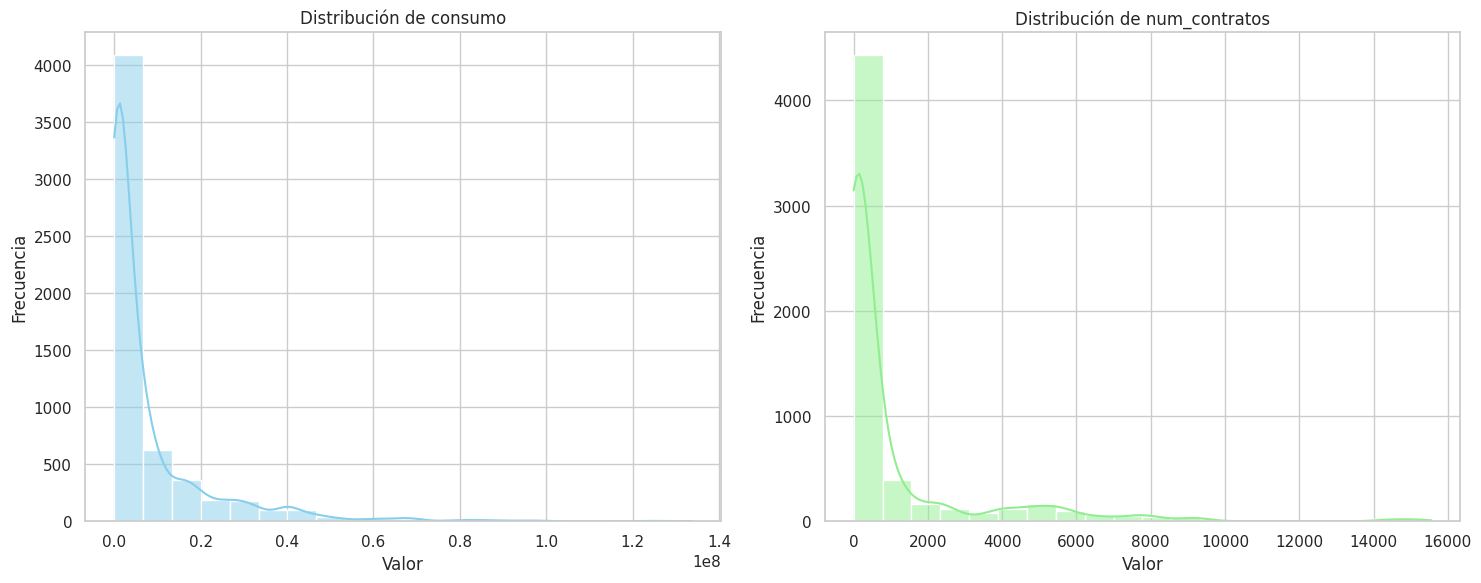

In [71]:
cols = 2
rows = (len(features) + cols - 1) // cols 

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))
axes = axes.flatten()

colors = ["skyblue", "lightgreen", "salmon", "plum"]
for idx, feature in enumerate(features):
    if idx < len(features):
        feature = features[idx]
        ax = axes[idx]
        
        sns.histplot(data=df, x=feature, kde=True, bins=20, ax=ax, color=colors[idx % 4])
        ax.set_title(f"Distribución de {feature}")
        ax.set_xlabel("Valor")
        ax.set_ylabel("Frecuencia")
    else:
        fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig(images_path / "distribuciones_univariadas.png", dpi=300, bbox_inches="tight")

# Relaciones Bivariadas

In [72]:
features = list(df.select_dtypes(include=[np.number]).corr())

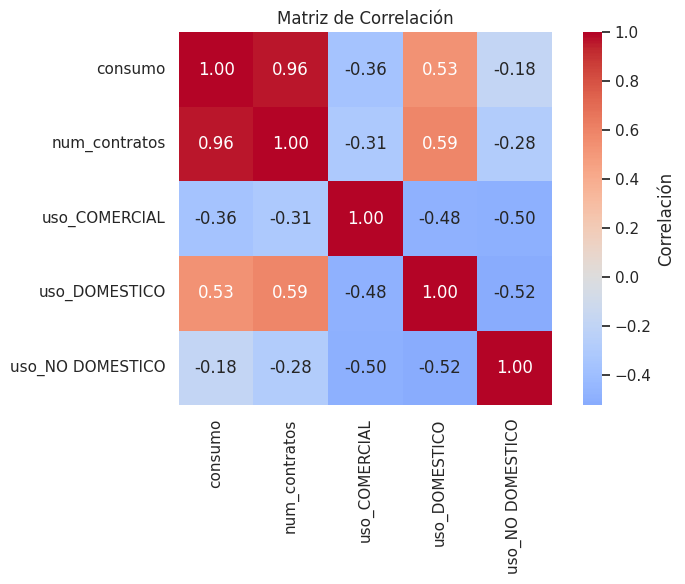

In [73]:
corr_matrix = df[features].corr()

# Visualización
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, 
            square=True, ax=ax, cbar_kws={"label": "Correlación"})
ax.set_title("Matriz de Correlación")
plt.tight_layout()
plt.savefig(images_path / "correlacion_matrix.png", dpi=300, bbox_inches="tight")


# Scatter Plots

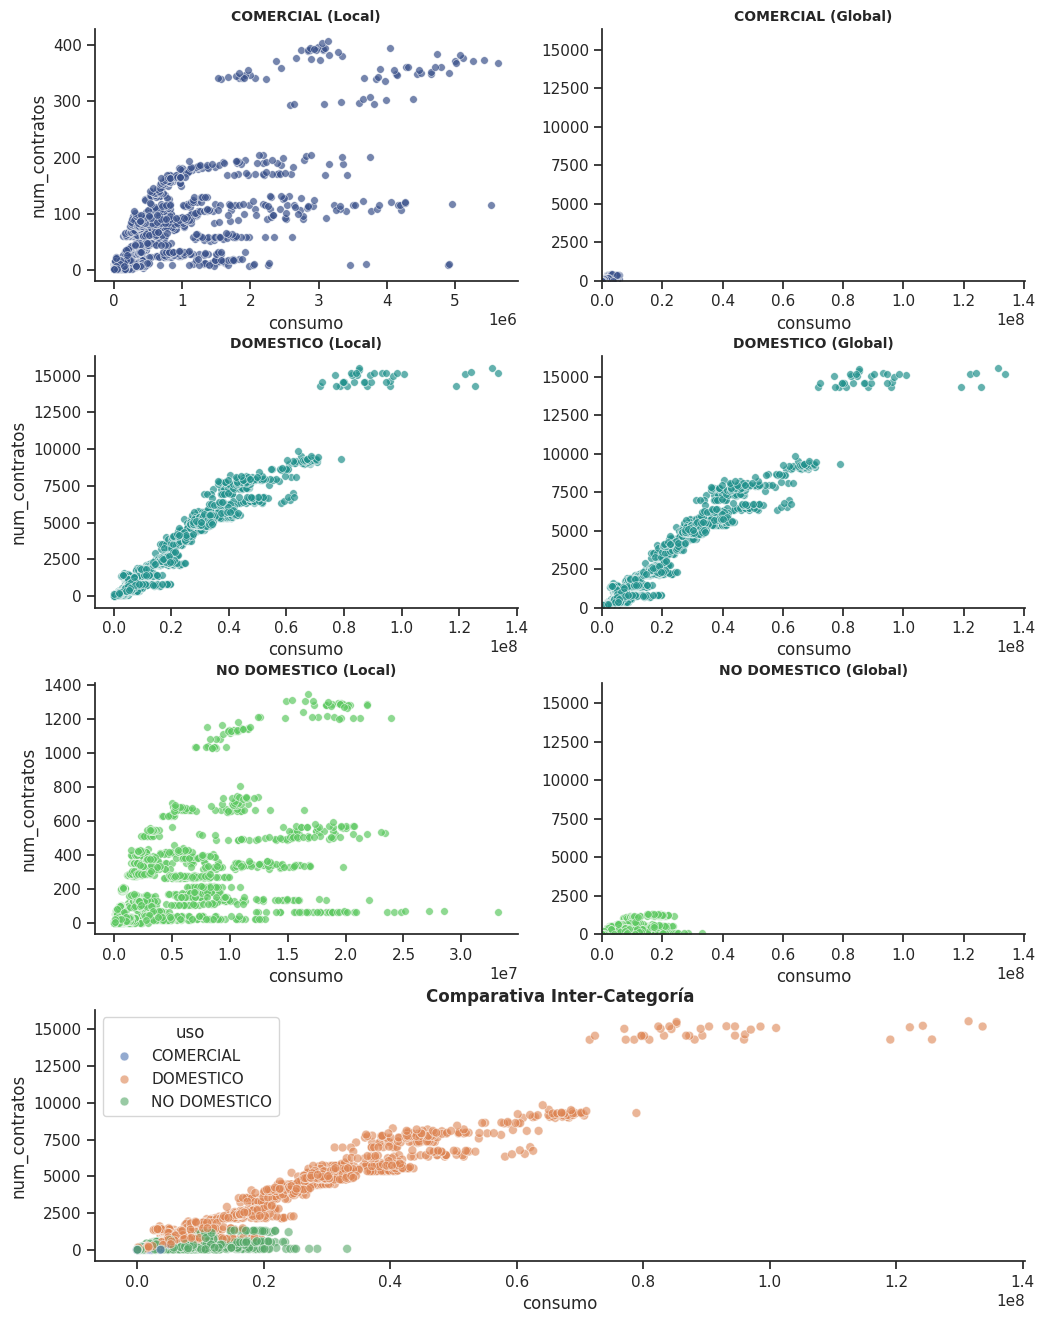

In [74]:
sns.set_theme(style="ticks")
palette_name = "viridis"

fig = plt.figure(figsize=(12, 16))
gs = fig.add_gridspec(4, 2, hspace=0.3, wspace=0.2)
lims = {"x": (0, df[DatasetKeys.CONSUMO].max() * 1.05), 
        "y": (0, df[DatasetKeys.NUM_CONTRATOS].max() * 1.05)}


tipos = df[DatasetKeys.USO].unique()
colores = sns.color_palette(palette_name, n_colors=len(tipos))

for i, tipo in enumerate(tipos):
    data = df[df[DatasetKeys.USO] == tipo]
    current_color = colores[i]
        
    # Columna 0: Escala Local | Columna 1: Escala Global
    for j in range(2):
        ax = fig.add_subplot(gs[i, j])
        sns.scatterplot(data=data, x=DatasetKeys.CONSUMO, y=DatasetKeys.NUM_CONTRATOS, ax=ax, s=30, alpha=0.7, color=current_color)
        if j == 1: 
            ax.set(xlim=lims["x"], ylim=lims["y"], ylabel="")
        ax.set_title(f"{tipo} ({"Global" if j==1 else "Local"})", fontsize=10, weight="bold")

# Comparativa Integral
ax_full = fig.add_subplot(gs[3, :])
sns.scatterplot(data=df, x=DatasetKeys.CONSUMO, y=DatasetKeys.NUM_CONTRATOS, 
                hue=DatasetKeys.USO, ax=ax_full, s=40, alpha=0.6)

ax_full.set_title("Comparativa Inter-Categoría", fontsize=12, weight="bold")
sns.despine()
plt.savefig(images_path / "scatter_plots.png", dpi=300, bbox_inches="tight")

# Imbalance y Representatividad

In [75]:
label = DatasetKeys.USO
df[label].value_counts()

uso
NO DOMESTICO    2016
DOMESTICO       1944
COMERCIAL       1815
Name: count, dtype: int64

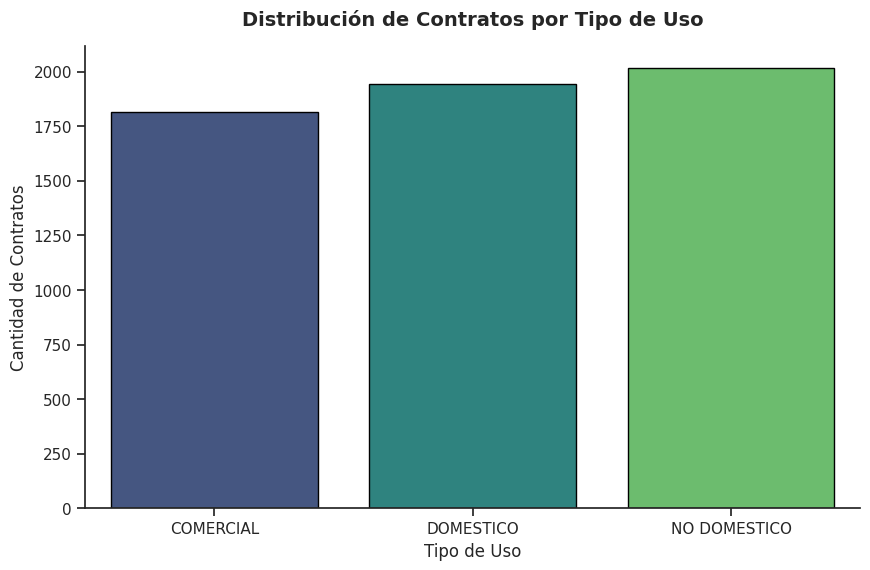

In [76]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(data=df, x=label, palette="viridis", hue=label, ax=ax,edgecolor="black",linewidth=1)
ax.set_title("Distribución de Contratos por Tipo de Uso", fontsize=14, weight="bold", pad=15)
ax.set_xlabel("Tipo de Uso", fontsize=12)
ax.set_ylabel("Cantidad de Contratos", fontsize=12)

sns.despine()
plt.savefig(images_path / "distribucion_usos.png", dpi=300, bbox_inches="tight")

# PCA visualization

In [77]:
features

['consumo',
 'num_contratos',
 'uso_COMERCIAL',
 'uso_DOMESTICO',
 'uso_NO DOMESTICO']

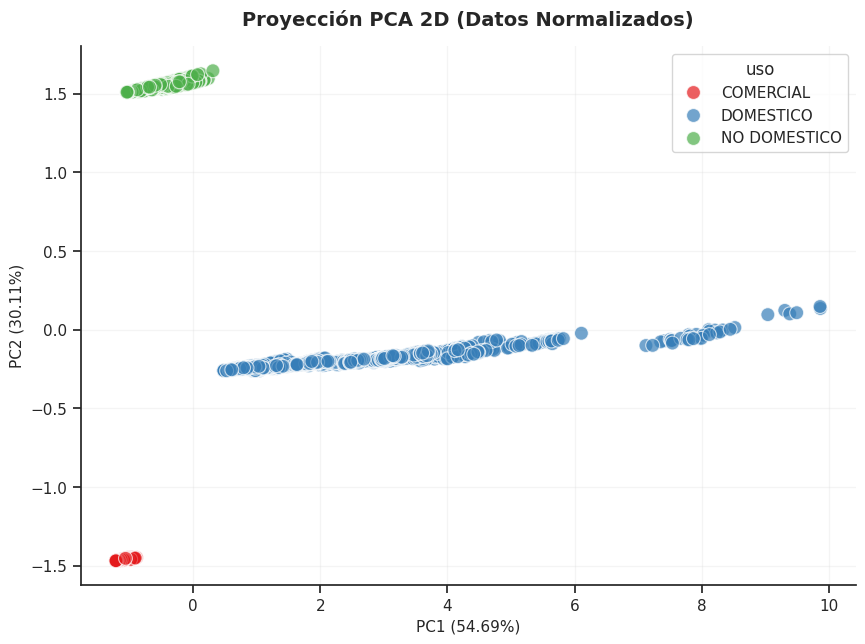

In [78]:
# Procesamiento (Escalado + PCA)
X_scaled = StandardScaler().fit_transform(df[features])
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

# Creación del DataFrame temporal para Seaborn
df_pca = pd.DataFrame(data=components, columns=["PC1", "PC2"])
df_pca[label] = df[label].values

# Visualización
sns.set_theme(style="ticks")
plt.figure(figsize=(10, 7))

ax = sns.scatterplot(
    data=df_pca, x="PC1", y="PC2", hue=label, 
    palette="Set1", s=100, alpha=0.7, edgecolor="w"
)

# Etiquetas dinámicas usando los ratios de varianza
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})", fontsize=11)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})", fontsize=11)
ax.set_title("Proyección PCA 2D (Datos Normalizados)", fontsize=14, weight="bold", pad=15)

sns.despine()
plt.grid(True, alpha=0.2)
plt.savefig(images_path / "pca_visualization.png", dpi=300, bbox_inches="tight")